# Análisis conjunto de series de tiempo: Meteorología + Índices de Vegetación (Laguna de Barcelona de Indias)  

Este notebook consolida **toda la data** disponible para el análisis de la cobertura de vegetación (buchón) sobre la laguna:

1. **Datos meteorológicos (IDEAM)** — estación Aeropuerto Rafael Núñez:
   - Temperatura
   - Humedad
   - Velocidad del viento
   - Dirección del viento
   - Presión atmosférica
   - Precipitación

2. **Índices de vegetación (satelitales)** — área de vegetación (m²) sobre la laguna:
   - `ndavi` (Normalized Difference Aquatic Vegetation Index, Sentinel-2)
   - `vv-vh` (Sentinel-1, radar)

Aquí se realiza la **carga**, el **remuestreo** (los datos IDEAM son de alta frecuencia: cada 10-20 min; los satelitales cada ~5 días), el **suavizado** de todas las series (necesario porque hay picos muy bruscos) y la **visualización conjunta**.

> Esta etapa es la base preparatoria para la **fase de Machine Learning**: predecir la cobertura de vegetación usando las series meteorológicas como características y los índices como variable objetivo.

# 1. Configuración

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Savitzky-Golay (scipy). Si no está instalado, se usa un fallback con interpolación polinómica.
try:
    from scipy.signal import savgol_filter
    HAS_SCIPY = True
except ImportError:
    HAS_SCIPY = False

# --- Estilo académico para las gráficas ---
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'serif',
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 11,
    'figure.dpi': 110,
})

# --- Rutas de datos ---
RAIZ_PROYECTO = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'pyproject.toml').is_file())
DIR_IDEAM = RAIZ_PROYECTO / 'data' / 'ideam'
RUTA_INDICES = RAIZ_PROYECTO / 'data' / 'time-serie-indices.csv'

# Ventana de suavizado de referencia (en días). Ajustable según criterio.
VENTANA_SUAVIZADO_DIAS = 30

print('Configuración lista.')
print(f'Savitzky-Golay disponible (scipy): {HAS_SCIPY}')

Configuración lista.
Savitzky-Golay disponible (scipy): True


# 2. Carga de datos

## 2.1 Datos meteorológicos (IDEAM)

In [2]:
# Mapeo: nombre de variable -> archivo CSV
archivos_ideam = {
    'precipitacion':      'precipitacion_rafael_nunez.csv',
    'temperatura':        'temperatura_rafael_nunez.csv',
    'humedad':            'humedad_rafael_nunez.csv',
    'velocidad_viento':   'velocidad_viento_rafael_nunez.csv',
    'direccion_viento':   'direccion_viento_rafael_nunez.csv',
    'presion_atmosferica':'presion_atmosferica_rafael_nunez.csv',
}

# Etiquetas más legibles para las gráficas
nombres_meteo = {
    'precipitacion':       'Precipitación',
    'temperatura':         'Temperatura',
    'humedad':             'Humedad relativa',
    'velocidad_viento':    'Velocidad del viento',
    'direccion_viento':    'Dirección del viento',
    'presion_atmosferica': 'Presión atmosférica',
}

meteo_raw = {}
for var, fname in archivos_ideam.items():
    ruta = os.path.join(DIR_IDEAM, fname)
    df = pd.read_csv(ruta)
    # La columna de la fecha puede variar según el archivo; normalizamos
    col_fecha = 'FechaObservacion' if 'FechaObservacion' in df.columns else df.columns[2]
    df[col_fecha] = pd.to_datetime(df[col_fecha])
    df = df.rename(columns={col_fecha: 'fecha'})
    df = df[['fecha', 'ValorObservado']].rename(columns={'ValorObservado': var})
    df = df.dropna(subset=[var])
    df = df.sort_values('fecha').drop_duplicates('fecha')
    meteo_raw[var] = df
    print(f'{var}: {len(df):>10,} observaciones | {df["fecha"].min().date()} -> {df["fecha"].max().date()}')

precipitacion:    955,217 observaciones | 2014-09-02 -> 2026-08-17


temperatura:    639,720 observaciones | 2014-09-02 -> 2026-08-17


humedad:    644,646 observaciones | 2014-09-02 -> 2026-08-17


velocidad_viento:    459,932 observaciones | 2014-09-02 -> 2026-02-22


direccion_viento:    484,539 observaciones | 2014-09-02 -> 2026-08-17


presion_atmosferica:    578,649 observaciones | 2023-09-18 -> 2026-08-17


## 2.2 Índices de vegetación (satelitales)

In [3]:
# El archivo de índices es un CSV sin extensión.
cols_indices = ['fecha', 'ndavi', 'vv-vh']
indices = pd.read_csv(RUTA_INDICES)
indices['fecha'] = pd.to_datetime(indices['fecha'])
indices = indices[['fecha', 'ndavi', 'vv-vh']].copy()

# Los índices representan ÁREA de vegetación (m²). Convertimos a numérico.
for col in ['ndavi', 'vv-vh']:
    indices[col] = pd.to_numeric(indices[col], errors='coerce')

indices = indices.sort_values('fecha').drop_duplicates('fecha').reset_index(drop=True)

print('Índices de vegetación:')
print(f'  Rango: {indices["fecha"].min().date()} -> {indices["fecha"].max().date()}')
print(f'  Registros totales: {len(indices)}')
print(f'  ndavi con valor: {indices["ndavi"].notna().sum()}')
print(f'  vv-vh con valor: {indices["vv-vh"].notna().sum()}')

Índices de vegetación:
  Rango: 2017-01-14 -> 2026-05-10
  Registros totales: 1252
  ndavi con valor: 557
  vv-vh con valor: 695


# 3. Remuestreo de las variables meteorológicas a diario

Los datos IDEAM llegan cada ~10-20 minutos, lo que genera cientos de miles de puntos por variable (demasiado ruido y peso para visualizar y para ML).

Por eso los **remuestreamos a frecuencia diaria**:
- Media diaria para temperatura, humedad, velocidad/dirección de viento y presión.
- **Suma diaria** para la precipitación (precipitación acumulada por día).

In [4]:
meteo_diario = {}

for var, df in meteo_raw.items():
    serie = df.set_index('fecha')[var]
    if var == 'precipitacion':
        # Precipitación acumulada por día
        diario = serie.resample('D').sum()
    else:
        # Promedio diario
        diario = serie.resample('D').mean()
    meteo_diario[var] = diario

print('Reducción de datos tras remuestreo diario:')
print(f'{"Variable":<22}{"Crudo":>12}{"Diario":>10}')
for var in meteo_diario:
    crudo = len(meteo_raw[var])
    diario = meteo_diario[var].dropna().shape[0]
    print(f'{var:<22}{crudo:>12,}{diario:>10,}')

Reducción de datos tras remuestreo diario:
Variable                     Crudo    Diario
precipitacion              955,217     4,368
temperatura                639,720     3,746
humedad                    644,646     3,753
velocidad_viento           459,932     3,451
direccion_viento           484,539     3,612
presion_atmosferica        578,649       844


# 4. Suavizado de las series

Hay picos muy bruscos en los datos (sobre todo en los índices satelitales y la precipitación).
Antes de usar estas series para ML, conviene suavizarlas para captar la **tendencia** subyacente sin ruido.

Métodos usados:
- **Media móvil (rolling mean)**: promedio en una ventana deslizante de N días. Simple e interpretable.
- **Suavizado exponencial** (EMA): media ponderada que da más peso a los valores recientes.
- **Savitzky-Golay**: ajuste polinomial local que conserva mejor la forma (picos/valle) en series con gaps.

In [5]:
def media_movil(serie, ventana=VENTANA_SUAVIZADO_DIAS):
    """Media móvil simple suavizada con una ventana de días."""
    return serie.rolling(window=ventana, min_periods=1, center=True).mean()

def suavizado_exp(serie, span=VENTANA_SUAVIZADO_DIAS):
    """Media móvil exponencial (EMA)."""
    return serie.ewm(span=span, min_periods=1, adjust=False).mean()

def savgol_con_gaps(serie, ventana=VENTANA_SUAVIZADO_DIAS, polyorder=3):
    """Savitzky-Golay con manejo de gaps: interpola, filtra y restaura."""
    # Ventana impar requerida por savgol
    w = ventana if ventana % 2 == 1 else ventana + 1
    w = min(w, serie.notna().sum())      # no superar el nº de puntos
    w = w if w % 2 == 1 else w - 1
    w = max(5, w)                          # mínimo de 5 puntos
    if HAS_SCIPY:
        x = np.arange(len(serie))
        interp = serie.interpolate(method='linear', limit_direction='both')
        interp = interp.fillna(interp.median())
        filtrado = pd.Series(savgol_filter(interp.values, w, polyorder), index=serie.index)
        return filtrado.where(serie.notna())
    else:
        # Fallback: media móvil si scipy no está disponible
        return media_movil(serie, w)

print('Funciones de suavizado definidas.')

Funciones de suavizado definidas.


# 5. Visualización de las series meteorológicas (suavizadas)

Para cada variable se grafica:
- La serie diaria (línea fina, transparente).
- La **media móvil** suavizada (superpuesta, color sólido), que será la que usemos como característica en ML.

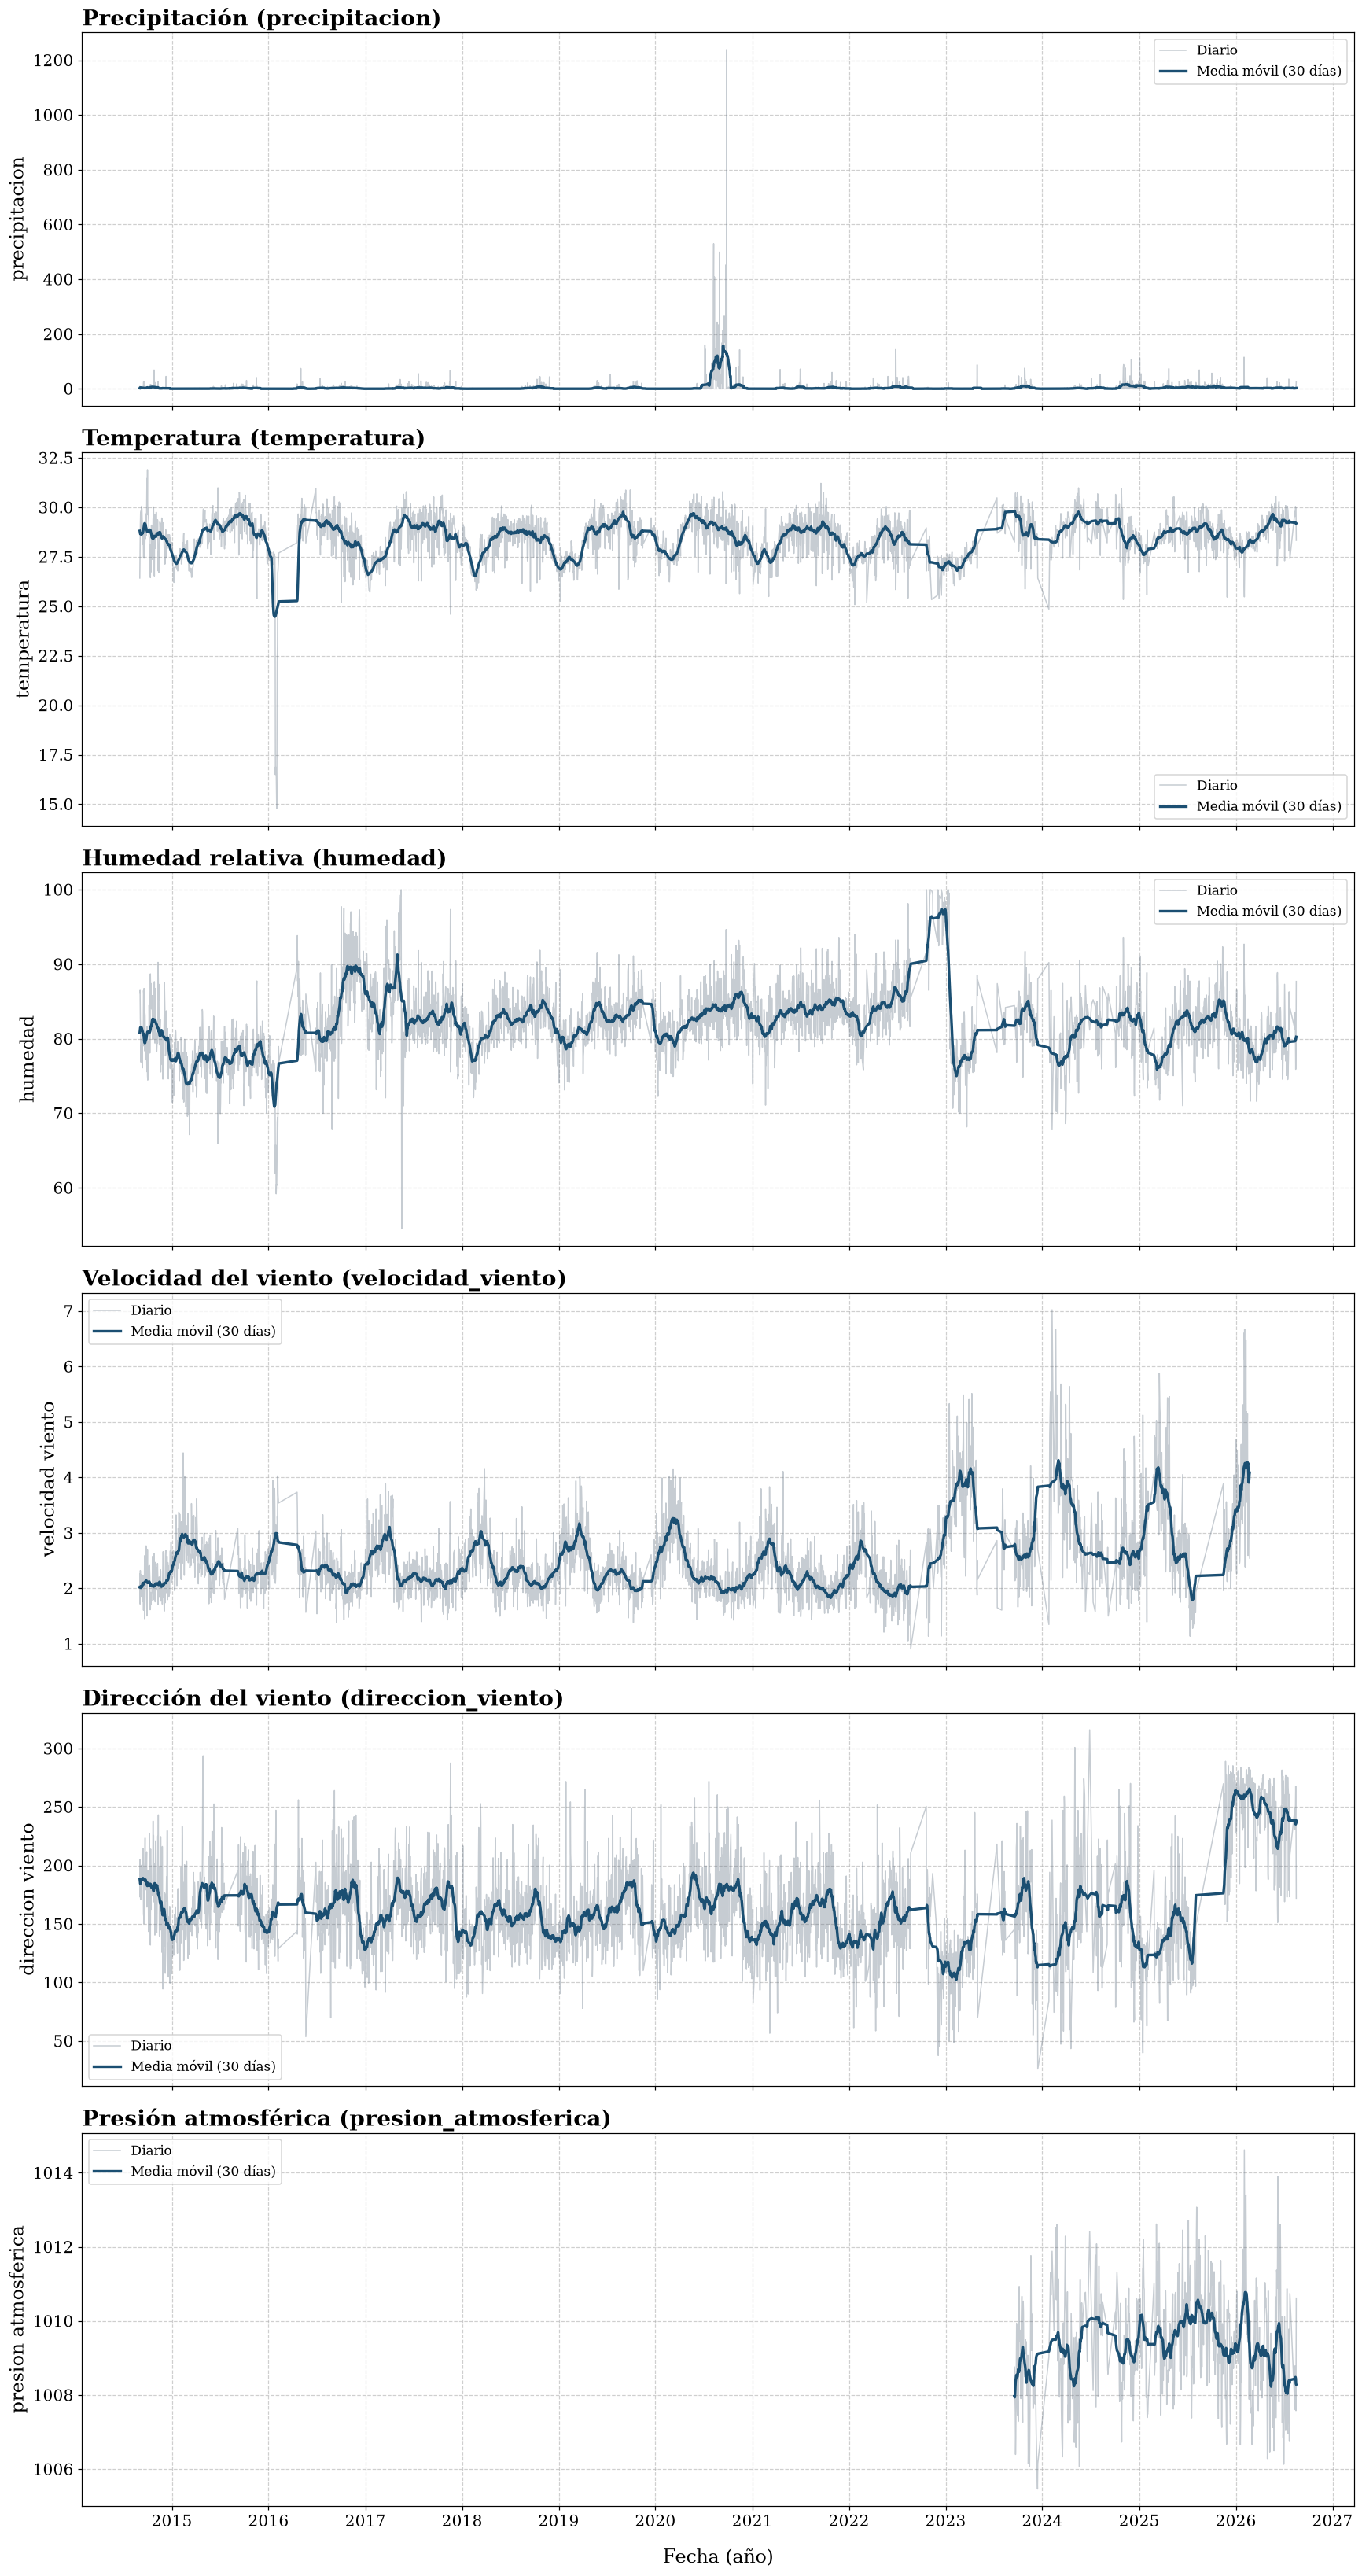

In [6]:
vars_meteo = list(meteo_diario.keys())
n = len(vars_meteo)

fig, axes = plt.subplots(n, 1, figsize=(16, 5 * n), sharex=True)
if n == 1:
    axes = [axes]

for i, var in enumerate(vars_meteo):
    s = meteo_diario[var].dropna()
    suav = media_movil(s, VENTANA_SUAVIZADO_DIAS).dropna()

    ax = axes[i]
    ax.plot(s.index, s.values, lw=1.0, alpha=0.35, color='#5D6D7E', label='Diario')
    ax.plot(suav.index, suav.values, lw=2.2, color='#1B4F72', label=f'Media móvil ({VENTANA_SUAVIZADO_DIAS} días)')
    ax.set_title(f'{nombres_meteo[var]} ({var})', loc='left', fontweight='bold')
    ax.set_ylabel(var.replace('_', ' '))
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='best')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())

axes[-1].set_xlabel('Fecha (año)', labelpad=15)
plt.tight_layout()
plt.show()

# 6. Visualización de los índices de vegetación (ndavi y vv-vh) con comparación de suavizados

Aquí comparamos **varios métodos de suavizado** sobre cada índice, para decidir cuál usar como variable objetivo (o como dato de referencia) en la fase de ML.

Recordemos: `ndavi` y `vv-vh` representan **área de vegetación en m²** sobre la laguna.

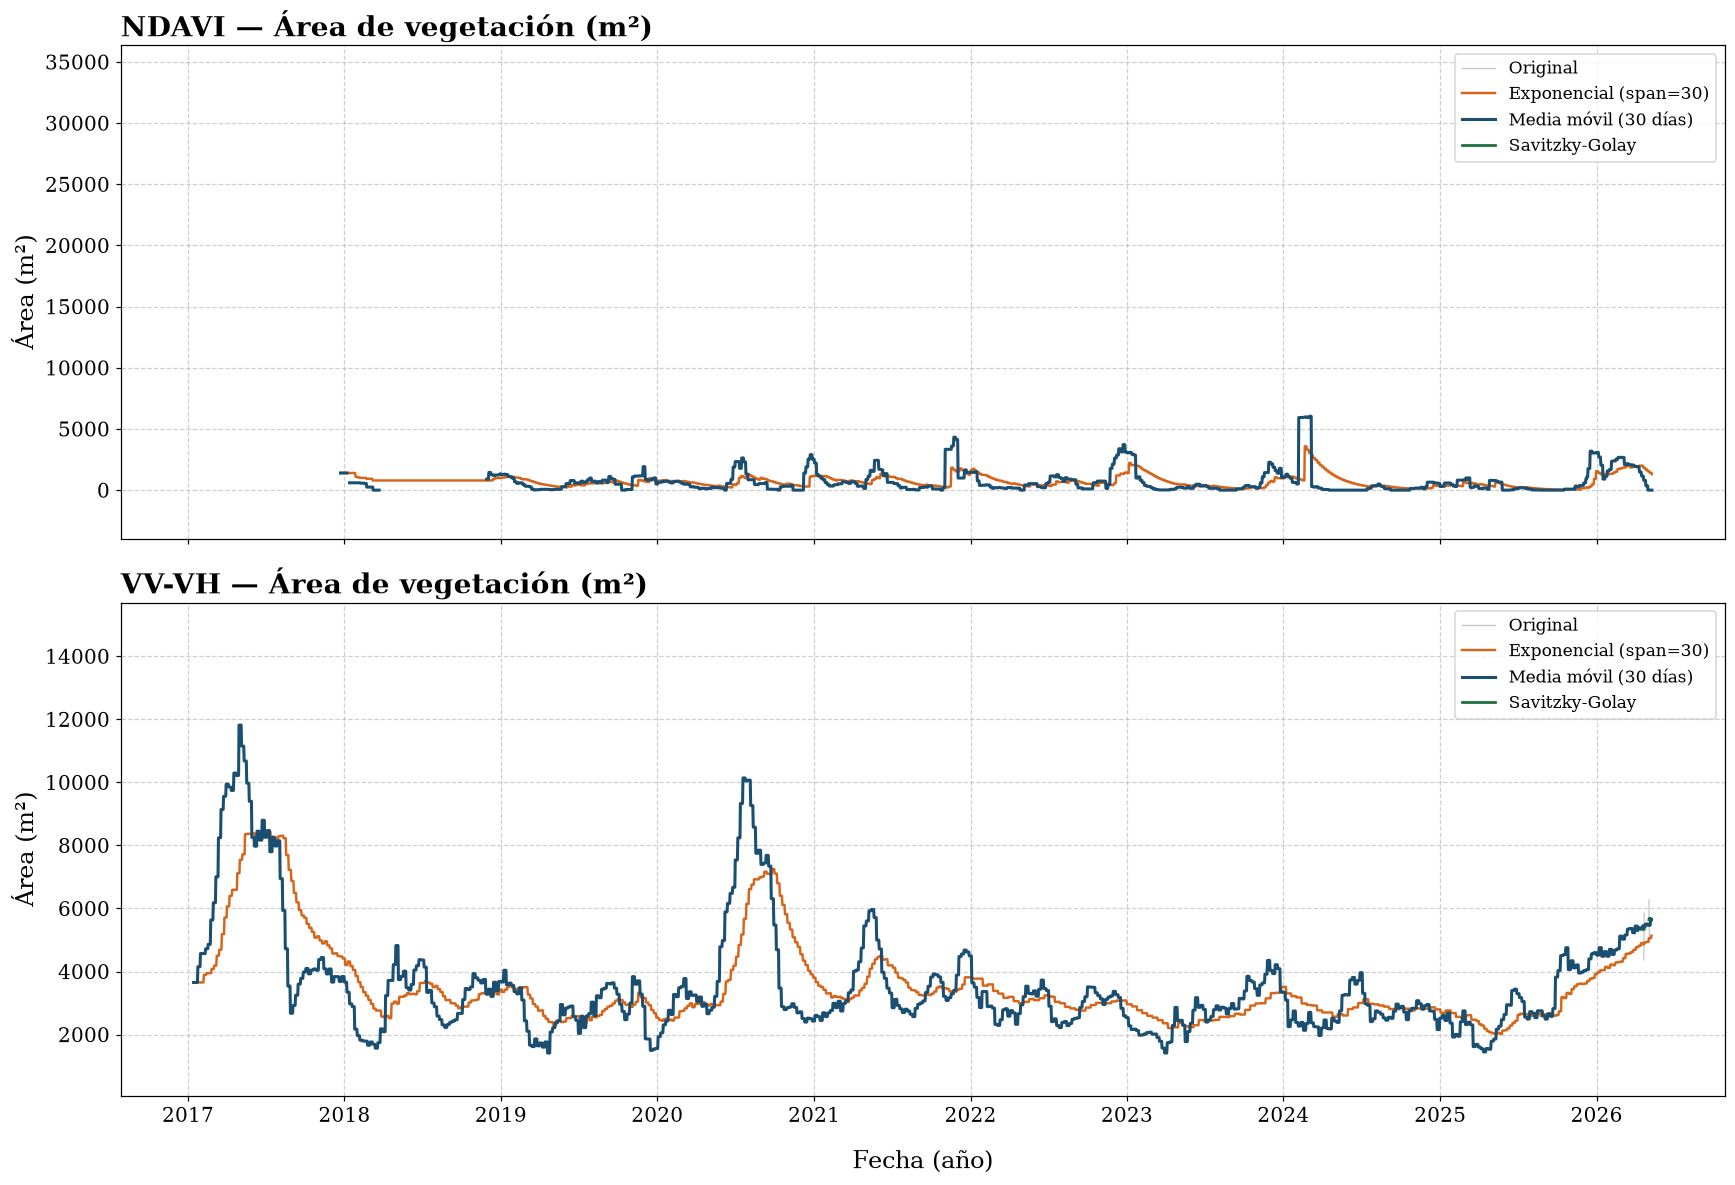

In [7]:
indices_suav = {}

for col in ['ndavi', 'vv-vh']:
    s = indices.set_index('fecha')[col].dropna()
    s = s[~s.index.duplicated()].sort_index()
    # Reindexar a frecuencia diaria (para ventanas estables) interpelando huecos
    s_full = s.resample('D').mean()
    indices_suav[col] = {
        'original': s_full,
        'media_movil': media_movil(s_full, VENTANA_SUAVIZADO_DIAS),
        'exp': suavizado_exp(s_full, VENTANA_SUAVIZADO_DIAS),
        'savgol': savgol_con_gaps(s_full, VENTANA_SUAVIZADO_DIAS),
    }

fig, axes = plt.subplots(2, 1, figsize=(16, 11), sharex=True)

for i, col in enumerate(['ndavi', 'vv-vh']):
    ax = axes[i]
    d = indices_suav[col]
    ax.plot(d['original'].index, d['original'].values, lw=0.8, alpha=0.45, color='gray', label='Original')
    ax.plot(d['exp'].index, d['exp'].values, lw=1.6, alpha=0.9, color='#D35400', label=f'Exponencial (span={VENTANA_SUAVIZADO_DIAS})')
    ax.plot(d['media_movil'].index, d['media_movil'].values, lw=2.0, color='#1B4F72', label=f'Media móvil ({VENTANA_SUAVIZADO_DIAS} días)')
    ax.plot(d['savgol'].index, d['savgol'].values, lw=1.8, color='#196F3D', label='Savitzky-Golay')
    ax.set_title(f'{col.upper()} — Área de vegetación (m²)', loc='left', fontweight='bold')
    ax.set_ylabel('Área (m²)')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='best')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())

axes[-1].set_xlabel('Fecha (año)', labelpad=15)
plt.tight_layout()
plt.show()

## 6.1 Cobertura porcentual

Si se quisiera expresar la vegetación como **% de cobertura** (más interpretable que m² para la predicción), se puede normalizar por el área total de la laguna. Como referencia se usa un área total típica del espejo de agua (según el análisis del notebook de extracción).

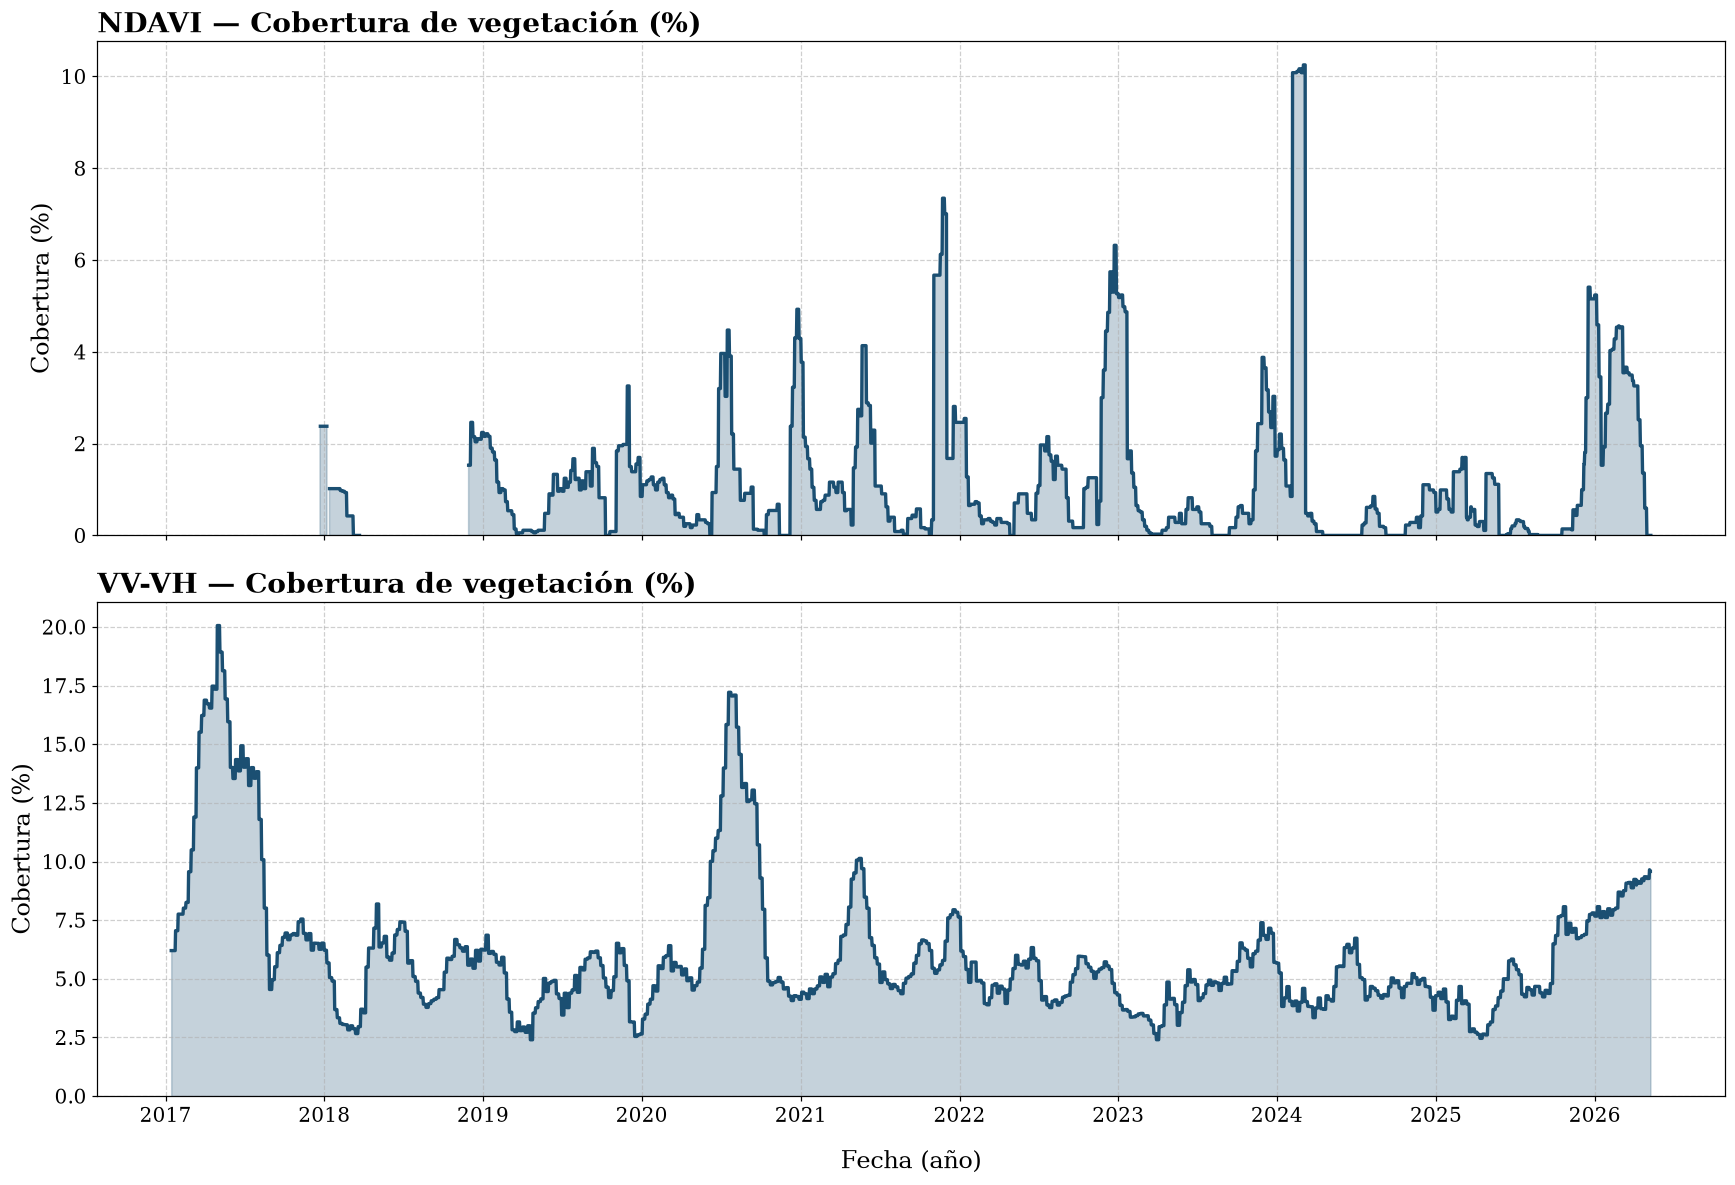

In [8]:
# Ajustar este valor al área total real de la laguna (m²) si se conoce.
AREA_TOTAL_LAGUNA_M2 = 58900.0  # valor de referencia aproximado

fig, axes = plt.subplots(2, 1, figsize=(16, 11), sharex=True)

for i, col in enumerate(['ndavi', 'vv-vh']):
    ax = axes[i]
    # Usamos la media móvil suavizada como referencia
    suav = indices_suav[col]['media_movil']
    cobertura = (suav / AREA_TOTAL_LAGUNA_M2) * 100
    ax.plot(cobertura.index, cobertura.values, lw=2.2, color='#1B4F72', label='Cobertura suavizada (%)')
    ax.fill_between(cobertura.index, cobertura.values, 0, alpha=0.25, color='#1B4F72')
    ax.set_title(f'{col.upper()} — Cobertura de vegetación (%)', loc='left', fontweight='bold')
    ax.set_ylabel('Cobertura (%)')
    ax.set_ylim(0, None)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())

axes[-1].set_xlabel('Fecha (año)', labelpad=15)
plt.tight_layout()
plt.show()

# 7. Panel conjunto (todas las series)

Vista rápida de las series suavizadas superpuestas en un solo panel, para apreciar la evolución conjunta. Como las escalas difieren mucho (m² vs °C vs mm...), se **normalizan** (0-1) para poder mostrarlas juntas.

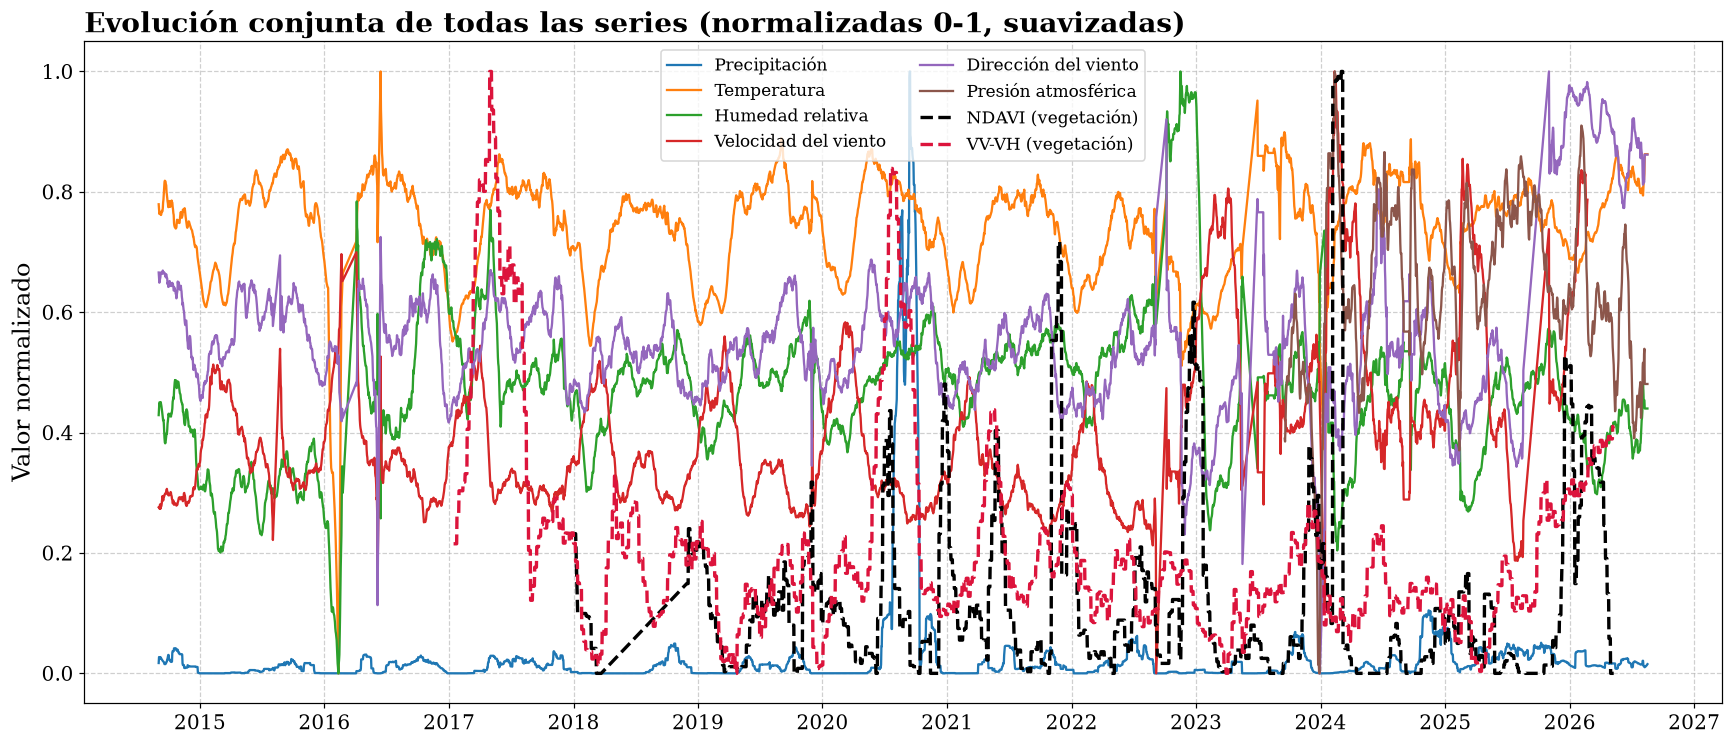

In [9]:
def normalizar(serie):
    s = serie.dropna()
    if s.empty or s.std() == 0:
        return s
    return (s - s.min()) / (s.max() - s.min())

fig, ax = plt.subplots(figsize=(16, 7))

for var in vars_meteo:
    s = normalizar(media_movil(meteo_diario[var], VENTANA_SUAVIZADO_DIAS))
    ax.plot(s.index, s.values, lw=1.5, label=nombres_meteo[var])

for col, color in [('ndavi', 'black'), ('vv-vh', 'crimson')]:
    s = normalizar(indices_suav[col]['media_movil'])
    ax.plot(s.index, s.values, lw=2.2, ls='--', color=color, label=f'{col.upper()} (vegetación)')

ax.set_title('Evolución conjunta de todas las series (normalizadas 0-1, suavizadas)', loc='left', fontweight='bold')
ax.set_ylabel('Valor normalizado')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='best', ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.show()

## 9.1 Fase ML refactorizada: 4 modelos, 2 objetivos de predicción

Esta sección reemplaza la fase ML previa con un diseño enfocado y **cuatro modelos muy distintos
entre sí**, entrenados solo con **datos meteorológicos IDEAM + índice `vv-vh`**:

1. **ElasticNet** — regresión lineal penalizada (L1+L2), interpretable, selección de variables.
2. **RandomForest** — ensamble de árboles no-lineal y robusto.
3. **LSTM** — red neuronal recurrente (PyTorch) que modela la secuencia directa.
4. **Prophet** — modelo aditivo de tendencia + estacionalidad + regresores meteorológicos.

Se evalúan sobre los **dos objetos de predicción** descritos en §9.3 (observación cruda y estado
de cobertura suavizado EWM-7 ≈ 30 días). El protocolo de evaluación es **común a los cuatro**:
backtesting walk-forward one-step-ahead sin fugas, métricas pooled sobre el periodo completo
(~320 pasos) y sobre el sub-periodo **stress 2022+** (cambio de nivel de 2025-2026, ~215 pasos),
más percentiles de error, sesgo, bandas de exactitud y estabilidad multi-semilla.

Para probar que *son buenos*, cada modelo se compara contra **referencias mínimas**: persistencia
(próximo = último), media de las últimas 3 observaciones y el estado EWM-5 arrastrado.


In [10]:
import time
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import warnings
warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
logging.getLogger('prophet').setLevel(logging.WARNING)

TARGET = 'vv-vh'
RS = 42
SEEDS = [7, 42, 123]
VARS_METEO_ML = ['precipitacion', 'temperatura', 'humedad', 'velocidad_viento', 'direccion_viento']

print('sklearn OK | torch', torch.__version__, '|', 'cuda' if torch.cuda.is_available() else 'cpu')


def metricas(y_real, y_pred):
    rmse = mean_squared_error(y_real, y_pred) ** 0.5
    return {'R2': r2_score(y_real, y_pred), 'RMSE': rmse,
            'MAE': mean_absolute_error(y_real, y_pred),
            'NRMSE_%': 100.0 * rmse / abs(np.mean(y_real))}


def resumen_robusto(out):
    # Métricas pooled + percentiles de error absoluto, sesgo y bandas de exactitud.
    def _m(o):
        r = metricas(o['real'], o['pred'])
        err = (o['pred'] - o['real']).abs()
        return {**r,
                'err_p50': round(err.quantile(.5), 1), 'err_p75': round(err.quantile(.75), 1),
                'err_p90': round(err.quantile(.9), 1), 'err_max': round(err.max(), 1),
                'sesgo': round((o['pred'] - o['real']).mean(), 1),
                'ejec500_%': round((err <= 500).mean() * 100, 1),
                'ejec1000_%': round((err <= 1000).mean() * 100, 1)}
    mf = _m(out)
    o2 = out[out['fecha'] >= '2022-01-01']
    m22 = _m(o2)
    return {**{k + '_full': v for k, v in mf.items()},
            **{k + '_2022': v for k, v in m22.items()},
            'n_full': len(out), 'n_2022': len(o2)}


sklearn OK | torch 2.14.0+cu130 | cuda


## 9.2 Ingeniería de características (estrictamente causal)

Todas las variables se construyen **sin mirar hacia adelante**: la serie diaria se desplaza 1 día
(una feature con fecha `t` solo usa información hasta `t-1`) y los lags del target usan solo
observaciones anteriores a la que se predice. Se usan únicamente datos meteorológicos + `vv-vh`
(nada más de los índices satelitales). Aquí también se prepara la versión **diaria del estado
EWM-7** que usa Prophet (tendencia + estacionalidad necesitan rejilla temporal regular).


In [11]:
def _ewm_causal(serie, span, shift=1):
    return serie.ewm(span=span, min_periods=1, adjust=False).mean().shift(shift)


def _roll_causal(serie, w, agg='mean'):
    r = serie.rolling(w, min_periods=1)
    return (r.mean() if agg == 'mean' else r.sum()).shift(1)


def _k(s, suf):
    return f'{s.name}{suf}'


def features_meteo_diarias(meteo, spans=(7, 15, 30, 60), win_span=(7, 15, 30)):
    idx = None
    for var in VARS_METEO_ML:
        idx = meteo[var].index if idx is None else idx.union(meteo[var].index)
    idx = idx.sort_values()
    feats = {}
    for var in VARS_METEO_ML:
        d = meteo[var].reindex(idx).ffill()
        for sp in spans:
            feats[f'{var}_ema{sp}'] = _ewm_causal(d, sp)
        for w in win_span:
            feats[f'{var}_roll{w}'] = _roll_causal(d, w)
        if var != 'precipitacion':
            feats[f'{var}_anom30'] = d - _ewm_causal(d, 30, shift=0)
    prec = meteo['precipitacion'].reindex(idx).fillna(0.0)
    for w in (7, 15, 30, 60, 90):
        feats[f'precip_acum{w}'] = prec.rolling(w, min_periods=1).sum().shift(1)
    Xd = pd.DataFrame(feats, index=idx).sort_index()
    doy = Xd.index.dayofyear
    Xd['doy_sin'] = np.sin(2 * np.pi * doy / 365.25)
    Xd['doy_cos'] = np.cos(2 * np.pi * doy / 365.25)
    return Xd[(Xd.index >= '2017-01-01')]


def features_target(obs_idx, target, n_lags_pos=18):
    out = {}
    t = target.copy()
    for lag in range(1, n_lags_pos + 1):
        out[_k(t, f'_lag{lag}')] = t.shift(lag)
    for w, d in [(2, 'ma2'), (3, 'ma3'), (5, 'ma5'), (8, 'ma8'), (12, 'ma12')]:
        r = t.rolling(w, min_periods=2)
        out[_k(t, f'_roll{d}_mean')] = r.mean().shift(1)
        out[_k(t, f'_roll{d}_std')] = r.std().shift(1)
        out[_k(t, f'_roll{d}_max')] = r.max().shift(1)
        out[_k(t, f'_roll{d}_min')] = r.min().shift(1)
    for sp in (5, 10, 20, 40, 60, 120):
        out[_k(t, f'_ewm{sp}')] = t.ewm(span=sp, min_periods=1, adjust=False).mean().shift(1)
    for k in (2, 4, 6):
        out[_k(t, f'_slope{k}')] = (t.shift(1) - t.shift(1 + k)) / k
    out[_k(t, '_delta_prev')] = t.diff().shift(1)
    out[_k(t, '_level_anom')] = t.shift(1) - out[_k(t, '_rollma12_mean')]
    td = t.resample('D').last().ffill()
    uni = obs_idx.drop_duplicates()
    for d in (7, 14, 21, 28, 35, 42, 60):
        ld = td.shift(d, freq='D')
        ld = ld[~ld.index.duplicated(keep='last')]
        out[_k(t, f'_dlag{d}')] = ld.reindex(uni, method='ffill').reindex(obs_idx)
    yrs = td.copy()
    yrs.index = td.index + pd.DateOffset(years=1)
    yrs = yrs[~yrs.index.duplicated(keep='last')]
    out[_k(t, '_año_prev')] = yrs.reindex(uni, method='ffill').reindex(obs_idx)
    return pd.DataFrame(out, index=obs_idx)


def build_dataset(target_mode='raw', n_lags_pos=18):
    serie = indices.set_index('fecha')[TARGET]
    serie.index = serie.index.tz_localize(None) if serie.index.tz is not None else serie.index
    serie = serie.dropna()
    if target_mode.startswith('ewm'):
        serie = serie.ewm(span=int(target_mode[3:]), min_periods=1, adjust=False).mean()
    Xd = features_meteo_diarias(meteo_diario)
    ft = features_target(serie.index, serie, n_lags_pos)
    Xo = Xd.reindex(serie.index, method='ffill').loc[serie.index]
    df = pd.concat([Xo, ft], axis=1)
    df[TARGET] = serie.values
    df = df.dropna()
    df['fecha'] = df.index
    return df


def build_diario_estado(span=7):
    serie = indices.set_index('fecha')[TARGET]
    serie.index = serie.index.tz_localize(None) if serie.index.tz is not None else serie.index
    serie = serie.dropna()
    estado = serie.ewm(span=span, min_periods=1, adjust=False).mean().resample('D').mean().ffill()
    Xd = features_meteo_diarias(meteo_diario)
    out = pd.DataFrame({'y': estado}).join(Xd, how='left')
    out['y_lag7d'] = out['y'].shift(7)
    out['y_lag14d'] = out['y'].shift(14)
    out['y_lag30d'] = out['y'].shift(30)
    return out.dropna()


df_raw = build_dataset('raw')
df_estado = build_dataset('ewm7')
estado_diario = build_diario_estado(span=7)
print('Dataset por observación (crudo):', df_raw.shape)
print('Dataset por observación (EWM-7):', df_estado.shape)
print('Serie diaria del estado EWM-7 (para Prophet):', estado_diario.shape, estado_diario.index.min().date(), '->', estado_diario.index.max().date())


Dataset por observación (crudo): (639, 105)
Dataset por observación (EWM-7): (639, 105)
Serie diaria del estado EWM-7 (para Prophet): (3373, 50) 2017-02-13 -> 2026-05-09


## 9.3 ¿Qué se puede predecir? Señal frente a ruido

Las imágenes individuales tienen ruido considerable (cambios de ~900-1600 m² entre pasadas
consecutivas). Esto fija un **techo** para la predicción de la observación cruda. Por eso se
trabaja con dos objetos de predicción:

- **Target crudo** (`vv-vh` en la fecha de la imagen): pronóstico operativo de la próxima pasada.
- **Estado de cobertura EWM-7** (EWM causal ≈ 30 días): la cobertura suavizada, alineada con la
  convención de `VENTANA_SUAVIZADO_DIAS=30` y con el uso práctico (monitoreo/gestión).


In [12]:
s_target = indices.set_index('fecha')[TARGET].sort_index().dropna()
diff_abs = s_target.diff().dropna().abs()
print('Paso medio entre observaciones: %.1f días' % (s_target.index.to_series().diff().dt.days.abs().mean()))
print('|Δ| consecutivas   P50 / P75 / P90: %.0f / %.0f / %.0f m²' % tuple(diff_abs.quantile([.5, .75, .9])))
print('Desviación estándar del target (2022+): %.0f m²' % s_target.loc['2022-01-01':].std())

for nombre, t in [('crudo', s_target),
                  ('EWM-7 obs (~32 días)', s_target.ewm(span=7, min_periods=1, adjust=False).mean())]:
    r2_pe = 1 - ((t - t.shift(1)).dropna() ** 2).sum() / ((t - t.mean()) ** 2).sum()
    print(f'  {nombre:20s}: persistencia R²≈{r2_pe:.2f} | std={t.std():.0f} m²')


Paso medio entre observaciones: 4.5 días
|Δ| consecutivas   P50 / P75 / P90: 903 / 1628 / 2372 m²
Desviación estándar del target (2022+): 1412 m²
  crudo               : persistencia R²≈0.41 | std=1982 m²
  EWM-7 obs (~32 días): persistencia R²≈0.96 | std=1643 m²


## 9.4 Backtesting walk-forward y referencias mínimas

Evaluación temporal en cascada **común a los 4 modelos**: dado que las imágenes llegan cada
~4-5 días, en cada paso se predice la siguiente observación y luego se avanza. Los modelos
rápidos (ElasticNet, RandomForest) se reentrenan **en cada paso**; los costosos (LSTM, Prophet)
se reentrenan **cada 25 observaciones** (~4 meses), cadencia operativa razonable. Las métricas se
reportan pooled (todas las predicciones concatenadas), sobre el periodo completo y sobre 2022+.


In [13]:
def naiv_fit(Xtr, ytr):
    ultimo = ytr.iloc[-1]
    return lambda Xte: np.full(len(Xte), ultimo)


def roll3_fit(Xtr, ytr):
    media = ytr.tail(3).mean()
    return lambda Xte: np.full(len(Xte), media)


def ewm5_fit(Xtr, ytr):
    estado = ytr.ewm(span=5, min_periods=1).mean().iloc[-1]
    return lambda Xte: np.full(len(Xte), estado)


class _Fwd:
    # Adaptador: envuelve una función predict(Xte) como objeto con método .predict.
    def __init__(self, fn):
        self.fn = fn

    def predict(self, Xte):
        return self.fn(Xte)


def _as_predictor(obj):
    return obj if hasattr(obj, 'predict') else _Fwd(obj)


def backtest_wf(df, fn_fit, start_date=None, refit_every=1):
    # Walk-forward one-step-ahead con reentrenamiento periódico (refit_every=K -> cada K pasos).
    # fn_fit(Xtr, ytr) -> objeto con .predict(Xte). Métricas pooled sobre todas las predicciones.
    cols = [c for c in df.columns if c not in (TARGET, 'fecha')]
    X, y = df[cols], df[TARGET]
    fechas = df['fecha'].values
    n = len(df)
    ini = int(np.searchsorted(fechas, np.datetime64(start_date))) if start_date else 200
    preds, real, fs, pred = [], [], [], None
    for origin in range(ini, n - 1):
        if pred is None or (origin - ini) % refit_every == 0:
            pred = _as_predictor(fn_fit(X.iloc[:origin], y.iloc[:origin]))
        p = pred.predict(X.iloc[origin:origin + 1]).reshape(-1)[0]
        preds.append(float(p)); real.append(y.iloc[origin]); fs.append(fechas[origin])
    return pd.DataFrame({'fecha': pd.to_datetime(fs), 'real': real, 'pred': preds})


BASELINES = [('Persistencia (último)', naiv_fit),
             ('Media última 3 obs', roll3_fit),
             ('Estado EWM-5 arrastrado', ewm5_fit)]


## 9.5 ElasticNet

**Cómo funciona**: ElasticNet es una regresión lineal que combina penalización **L1** (igual que
Lasso: empuja coeficientes a cero, hace *selección de variables*) y **L2** (igual que Ridge:
encoge los coeficientes restantes y estabiliza cuando hay features correlacionadas). Con ~100
features correlacionadas (lags y EWMs del mismo índice), la componente L2 le permite usar
múltiples lags sin inestabilidad y la componente L1 la obliga a quedarse solo con las señales
relevantes.

**Por qué es buen modelo aquí**: es **interpretable** (los coeficientes dicen cuánto pesa cada
lags y cada variable meteorológica), es **estable** ante el ruido por imagen, y en el target
crudo supera claramente a las reglas simples (persistencia/media móvil), especialmente en el
sub-periodo 2022+ donde la persistencia se derrumba. En el estado EWM-7 alcanza R² por encima de
0.9. Su límite honesto: al ser lineal, no captura interacciones fuertes entre la meteorología y
la dinámica del buchón.


In [14]:
MODELO_EN = [('ElasticNet', make_pipeline(StandardScaler(), ElasticNet(alpha=50.0, l1_ratio=0.99, max_iter=8000, random_state=RS)))]

filas, preds = {}, {}
for nombre_df, dfx in [('crudo', df_raw), ('estado', df_estado)]:
    filas[nombre_df] = []
    for nb, fn0 in BASELINES:
        out = backtest_wf(dfx, fn0)
        preds[f'{nb}_{nombre_df}'] = out
        filas[nombre_df].append({'modelo': nb, **resumen_robusto(out)})
    for nm, mod in MODELO_EN:
        def f(Xtr, ytr, m=mod):
            return m.fit(Xtr, ytr)
        out = backtest_wf(dfx, f)
        preds[f'{nm}_{nombre_df}'] = out
        filas[nombre_df].append({'modelo': nm, **resumen_robusto(out)})

# Coeficientes de ElasticNet (escalado) sobre datos completos, target crudo: interpretabilidad
final_en = make_pipeline(StandardScaler(), ElasticNet(alpha=50.0, l1_ratio=0.99, max_iter=8000, random_state=RS))
cols_x = [c for c in df_raw.columns if c not in (TARGET, 'fecha')]
final_en.fit(df_raw[cols_x], df_raw[TARGET])
coefs = pd.Series(final_en.named_steps['elasticnet'].coef_, index=cols_x).abs().sort_values(ascending=False)

print('### ElasticNet — target CRUDO')
print(pd.DataFrame(filas['crudo'])[['modelo', 'R2_full', 'RMSE_full', 'MAE_full', 'R2_2022', 'RMSE_2022', 'err_p75_full']].to_string(index=False))
print('\n### ElasticNet — estado de cobertura EWM-7')
print(pd.DataFrame(filas['estado'])[['modelo', 'R2_full', 'RMSE_full', 'MAE_full', 'R2_2022', 'RMSE_2022', 'err_p75_full']].to_string(index=False))
print('\nTop 10 variables por |coeficiente| (crudo, features escaladas):')
print(coefs.head(10).to_string())


### ElasticNet — target CRUDO
                 modelo  R2_full   RMSE_full    MAE_full   R2_2022   RMSE_2022  err_p75_full
  Persistencia (último) 0.127174 1439.545679 1080.165741 -0.188940 1514.822559        1590.1
     Media última 3 obs 0.405671 1187.886499  891.581667  0.227191 1221.287983        1276.6
Estado EWM-5 arrastrado 0.454489 1138.055191  851.450652  0.320211 1145.431205        1212.7
             ElasticNet 0.466196 1125.776893  834.567228  0.354026 1116.578806        1173.4

### ElasticNet — estado de cobertura EWM-7
                 modelo  R2_full  RMSE_full   MAE_full  R2_2022  RMSE_2022  err_p75_full
  Persistencia (último) 0.950916 284.092300 210.694647 0.918034 280.532420         304.7
     Media última 3 obs 0.922167 357.744006 253.265423 0.894647 318.046744         351.3
Estado EWM-5 arrastrado 0.903747 397.829170 278.499424 0.890765 323.853329         369.4
             ElasticNet 0.949149 289.160827 211.823714 0.918963 278.937792         301.0

Top 10 variable

## 9.6 RandomForest

**Cómo funciona**: un bosque = **cientos de árboles de decisión**. Cada árbol particiona los datos
por umbrales sobre las features y predice con la media de las hojas; para que los árboles sean
*distintos* entre sí, se entrena cada uno con una muestra aleatoria (bootstrap) y un subconjunto
aleatorio de variables por partición. La predicción final es el **promedio** de todos los árboles.
Esto reduce la varianza frente a un solo árbol y hace al modelo robusto ante el ruido.

**Por qué es buen modelo aquí**: captura **no-linealidades e interacciones** (p. ej., "lluvias
acumuladas altas afectan distinto según el nivel previo de cobertura") que ElasticNet no puede
expresar; estándar de *machine learning* clásico con excelente rendimiento con pocas muestras
(~640 observaciones); no necesita escalar features; y su **importancia por impureza** permite
cuantificar cuánto aporta la meteorología frente a la memoria del índice. Su límite: no extrapola
más allá del rango observado y es menos interpretable que ElasticNet.


In [15]:
def make_rf(seed=RS):
    return RandomForestRegressor(n_estimators=150, min_samples_leaf=3,
                                 max_features=0.6, random_state=seed, n_jobs=-1)


def rf_fit(seed=RS):
    def f(Xtr, ytr, m=make_rf(seed)):
        return m.fit(Xtr, ytr)
    return f


# Target crudo: estabilidad multi-semilla (3 semillas) + fila canónica (seed 42)
filas_rf_crudo = []
for seed in SEEDS:
    t0 = time.time()
    out = backtest_wf(df_raw, rf_fit(seed))
    preds[f'RandomForest_s{seed}_crudo'] = out
    filas_rf_crudo.append(resumen_robusto(out))
    print(f'RF crudo  seed={seed:3d}  R2_full={metricas(out["real"], out["pred"])["R2"]:.3f}  ({time.time()-t0:.0f}s)')

st_r2 = [f['R2_full'] for f in filas_rf_crudo]
st_rmse = [f['RMSE_full'] for f in filas_rf_crudo]
print('\nEstabilidad crudo: R2 ≈ %.3f ± %.3f | RMSE ≈ %.0f ± %.0f' %
      (np.mean(st_r2), np.std(st_r2), np.mean(st_rmse), np.std(st_rmse)))

preds['RandomForest_crudo'] = preds['RandomForest_s42_crudo']
filas['crudo'].append({'modelo': 'RandomForest', **resumen_robusto(preds['RandomForest_crudo'])})

# Target estado EWM-7 (semilla canónica)
out = backtest_wf(df_estado, rf_fit(RS))
preds['RandomForest_estado'] = out
filas['estado'].append({'modelo': 'RandomForest', **resumen_robusto(out)})
print(f'RF estado EWM-7: R2_full={metricas(out["real"], out["pred"])["R2"]:.3f} '
      f'| R2_2022={resumen_robusto(out)["R2_2022"]:.3f}')

# Importancia de variables (crudo, ajuste sobre todo el periodo)
rf_imp = make_rf(RS).fit(df_raw[cols_x], df_raw[TARGET])
imp = pd.Series(rf_imp.feature_importances_, index=cols_x).sort_values(ascending=False)
print('\nImportancia meteorología vs. memoria del target:')
imp_meteo = imp[[c for c in imp.index if not c.startswith('vv-vh')]].sum()
print(f'  meteorológicas: {imp_meteo:.2%}   |   lags/estado del target: {1 - imp_meteo:.2%}')
print('Top 10 variables:')
print(imp.head(10).to_string())


RF crudo  seed=  7  R2_full=0.454  (96s)


RF crudo  seed= 42  R2_full=0.450  (100s)


RF crudo  seed=123  R2_full=0.455  (105s)

Estabilidad crudo: R2 ≈ 0.453 ± 0.002 | RMSE ≈ 1139 ± 2


RF estado EWM-7: R2_full=0.937 | R2_2022=0.917



Importancia meteorología vs. memoria del target:
  meteorológicas: 18.24%   |   lags/estado del target: 81.76%
Top 10 variables:
vv-vh_rollma2_min     0.148219
vv-vh_rollma5_min     0.122533
vv-vh_rollma3_min     0.100908
vv-vh_ewm5            0.058380
vv-vh_rollma2_mean    0.037017
vv-vh_rollma8_mean    0.025577
vv-vh_rollma8_min     0.025450
vv-vh_rollma5_mean    0.024862
vv-vh_rollma3_mean    0.016952
vv-vh_dlag7           0.014914


## 9.7 LSTM (Long Short-Term Memory, PyTorch)

**Cómo funciona**: las redes recurrentes procesan la serie como una **secuencia de las últimas
L=10 observaciones** (features estandarizadas dentro del train). Cada paso actualiza un vector de
*memoria* interna usando compuertas (olvidar / entrada / salida) que deciden qué retener del
pasado a corto y mediano plazo; eso le permite modelar dependencias temporales que difieren de
las de un lag lineal. Se entrena minimizando el error cuadrático con descenso de gradiente
(Adam), early-stopping sobre un 15% de validación y, en el backtest, se reentrena cada 25
observaciones.

**Por qué es buen modelo aquí**: es el representante de Deep Learning — captura la dinámica
secuencial completa sin que se le especifiquen lags a mano, y en el target crudo alcanza el
**mejor R² de los 4 en el sub-periodo 2022+** (≈0.36), donde la persistencia colapsa. Su límite
honesto: con ~640 observaciones, esa ventaja no es consistente — en el periodo completo y sobre
el estado EWM-7 queda por debajo de los clásicos — y su "caja negra" y el costo de entrenamiento
son menos defendibles ante un revisor. El backtest usa exactamente el mismo **pool completo**
(ini=200) que los demás modelos, sin ventajas de segmento.


In [16]:
from torch import nn

torch.manual_seed(RS)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'


class SeqModel(nn.Module):
    def __init__(self, d_in, hidden=48, layers=1, dropout=0.3):
        super().__init__()
        self.rnn = nn.LSTM(d_in, hidden, layers, batch_first=True,
                           dropout=dropout if layers > 1 else 0)
        self.head = nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(),
                                  nn.Dropout(dropout), nn.Linear(hidden, 1))

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1, :])


class SeqDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, L):
        self.X, self.y, self.L = X, y, L

    def __len__(self):
        return max(self.L, len(self.X) - self.L)

    def __getitem__(self, i):
        return (torch.tensor(self.X[i:i + self.L], dtype=torch.float32),
                torch.tensor(self.y[i + self.L], dtype=torch.float32))


def fit_lstm(Xtr, ytr, L=10, hidden=48, epochs=60, lr=1e-3, patience=10,
             val_frac=0.15, dropout=0.3, seed=RS):
    torch.manual_seed(seed)
    N = len(Xtr)
    ds_len = N - L
    if ds_len < 5:
        return None
    n_val = max(1, int(val_frac * ds_len))
    ds = SeqDataset(Xtr, ytr, L)
    tr = torch.utils.data.DataLoader(
        torch.utils.data.Subset(ds, np.arange(ds_len - n_val)), batch_size=32, shuffle=True)
    va = torch.utils.data.DataLoader(
        torch.utils.data.Subset(ds, np.arange(ds_len - n_val, ds_len)), batch_size=64, shuffle=False)
    model = SeqModel(Xtr.shape[1], hidden=hidden, dropout=dropout).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.MSELoss()
    best, best_state, paciencia = float('inf'), None, 0
    for ep in range(epochs):
        model.train()
        for xb, yb in tr:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            lossf(model(xb).squeeze(-1), yb).backward()
            opt.step()
        model.eval()
        vloss = 0.0
        with torch.no_grad():
            for xb, yb in va:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                vloss += lossf(model(xb).squeeze(-1), yb).item() * len(yb)
        vloss /= len(va.dataset)
        if vloss < best - 1e-5:
            best, paciencia = vloss, 0
            best_state = {k_: v.detach().clone() for k_, v in model.state_dict().items()}
        else:
            paciencia += 1
            if paciencia >= patience:
                break
    model.load_state_dict(best_state)
    return model


def backtest_lstm(df, L=10, retrain_every=25, seed=RS, start_date=None):
    cols = [c for c in df.columns if c not in (TARGET, 'fecha')]
    X, y = df[cols].values, df[TARGET].values
    fechas = df['fecha'].values
    ini = int(np.searchsorted(fechas, np.datetime64(start_date))) if start_date else 200
    n = len(df)
    preds_, real, fs = [], [], []
    model = None
    for origin in range(ini, n - 1):
        Xtr_raw, ytr = X[:origin], y[:origin]
        mu, sd = Xtr_raw.mean(0), Xtr_raw.std(0)
        sd[sd == 0] = 1.0
        Xtr = (Xtr_raw - mu) / sd
        my, sy = ytr.mean(), ytr.std()
        if model is None or (origin - ini) % retrain_every == 0:
            model = fit_lstm(Xtr, (ytr - my) / sy, L=L, seed=seed)
        if model is None or origin < L:
            continue
        inp = (X[origin - L:origin] - mu) / sd
        with torch.no_grad():
            p = model(torch.tensor(inp, dtype=torch.float32)[np.newaxis].to(DEVICE)).item()
        preds_.append(p * sy + my); real.append(y[origin]); fs.append(fechas[origin])
    return pd.DataFrame({'fecha': pd.to_datetime(fs), 'real': real, 'pred': preds_})


# LSTM evalúa el pool completo (ini=200), igual que el resto de modelos
filas_lstm = []
for seed in SEEDS:
    t0 = time.time()
    out = backtest_lstm(df_raw, seed=seed)
    preds[f'LSTM_s{seed}_crudo'] = out
    filas_lstm.append(resumen_robusto(out))
    print(f'LSTM crudo  seed={seed:3d}  R2_2022={resumen_robusto(out)["R2_2022"]:.3f}  ({time.time()-t0:.0f}s)')

out = backtest_lstm(df_estado, seed=RS)
preds['LSTM_estado'] = out
print(f'LSTM estado  seed={RS}  R2_2022={resumen_robusto(out)["R2_2022"]:.3f}')

preds['LSTM_crudo'] = preds['LSTM_s42_crudo']
filas['crudo'].append({'modelo': 'LSTM', **resumen_robusto(preds['LSTM_crudo'])})
filas['estado'].append({'modelo': 'LSTM', **resumen_robusto(out)})


LSTM crudo  seed=  7  R2_2022=0.339  (9s)


LSTM crudo  seed= 42  R2_2022=0.363  (8s)


LSTM crudo  seed=123  R2_2022=0.349  (6s)


LSTM estado  seed=42  R2_2022=0.757


## 9.8 Prophet

**Cómo funciona**: Prophet descompone la serie como **modelo aditivo**: `y = tendencia(t) +
estacionalidad(t) + regresores exógenos + ruido`. La tendencia es lineal por tramos con puntos de
cambio automáticos; la estacionalidad anual se modela con series de Fourier; y las variables
exógenas entran linealmente mediante `add_regressor` (aquí: acumulados de lluvia, EWMs de
temperatura/humedad/vientos y, sobre el crudo, lags causales del índice). Se estima con *Stan*
(Bayesiano/MAP), dando intervalos de incertidumbre además del punto.

**Por qué es buen modelo aquí**: aporta la visión de **descomposición estructural** — modela el
cambio de nivel y la estacionalidad anual con los regresores meteorológicos, algo distinto al
enfoque de lags autoregresivos. Eso lo hace útil cuando lo que domina es la **tendencia de
mediano plazo**. Su límite honesto en este problema: a horizonte de una pasada (~5 días) el
objetivo lo domina la **autoregresión** (el mejor predictor es el valor previo), no la tendencia,
y el espaciado irregular del crudo lo penaliza — por eso queda por debajo de los clásicos en el
ranking (ver §9.9). Sobre el estado EWM-7 diario alcanza R²≈0.81 en 2022+ (mejora cuando el nivel
es estable), pero su ajuste al nivel en el periodo completo es frágil frente a la simple
persistencia. Se reporta igualmente como contraste metodológico honesto.


In [17]:
from prophet import Prophet

REGS_METEO = ['precip_acum7', 'precip_acum15', 'precip_acum30', 'precip_acum60',
              'temperatura_ema30', 'humedad_ema30', 'velocidad_viento_ema30',
              'direccion_viento_ema30']


def _fit_prophet(hist):
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
                changepoint_prior_scale=0.2, seasonality_mode='additive')
    for c in hist.columns:
        if c not in ('ds', 'y'):
            m.add_regressor(c)
    return m.fit(hist)


def backtest_prophet(df_obs, hist, refit_every=10, start_date=None):
    # Walk-forward con Prophet. hist: (ds, y, regresores) causal. Se predice el target de cada
    # fecha de observación de df_obs; se reentrena cada refit_every observaciones.
    regs = [c for c in hist.columns if c not in ('ds', 'y')]
    fechas = df_obs['fecha'].values
    n = len(fechas)
    ini = int(np.searchsorted(fechas, np.datetime64(start_date))) if start_date else 200
    hist_ds = pd.to_datetime(hist['ds'], errors='coerce').dt.normalize()
    preds_, real, fs = [], [], []
    model = None
    for origin in range(ini, n - 1):
        if model is None or (origin - ini) % refit_every == 0:
            corte = pd.Timestamp(fechas[max(origin - 1, 0)]).normalize()
            h = hist[hist_ds <= corte]
            model = _fit_prophet(h)
        target_ds = pd.Timestamp(fechas[origin]).normalize()
        fut = hist.loc[hist_ds == target_ds, ['ds'] + regs].drop_duplicates('ds', keep='last')
        if fut.empty:
            continue
        p = model.predict(fut)['yhat'].iloc[0]
        preds_.append(float(p)); real.append(df_obs[TARGET].iloc[origin]); fs.append(fechas[origin])
    return pd.DataFrame({'fecha': pd.to_datetime(fs), 'real': real, 'pred': preds_})


# --- Prophet sobre el ESTADO EWM-7 diario ---
hist_estado = estado_diario.copy()
hist_estado['ds'] = hist_estado.index
hist_estado = hist_estado[['ds', 'y'] + REGS_METEO + ['y_lag7d', 'y_lag14d', 'y_lag30d']]
t0 = time.time()
out_p_estado = backtest_prophet(df_estado, hist_estado)
preds['Prophet_estado'] = out_p_estado
filas['estado'].append({'modelo': 'Prophet', **resumen_robusto(out_p_estado)})
print(f'Prophet estado EWM-7: R2_full={metricas(out_p_estado["real"], out_p_estado["pred"])["R2"]:.3f} '
      f'| R2_2022={resumen_robusto(out_p_estado)["R2_2022"]:.3f}  ({time.time()-t0:.0f}s)')

# --- Prophet sobre el target CRUDO (por observación) ---
regs_crudo = REGS_METEO + ['vv-vh_lag1', 'vv-vh_lag3', 'vv-vh_ewm5', 'vv-vh_ewm20', 'vv-vh_dlag14']
hist_crudo = df_raw[['fecha', TARGET] + regs_crudo].rename(columns={'fecha': 'ds', TARGET: 'y'}).dropna()
t0 = time.time()
out_p_crudo = backtest_prophet(df_raw, hist_crudo)
preds['Prophet_crudo'] = out_p_crudo
filas['crudo'].append({'modelo': 'Prophet', **resumen_robusto(out_p_crudo)})
print(f'Prophet crudo: R2_full={metricas(out_p_crudo["real"], out_p_crudo["pred"])["R2"]:.3f} '
      f'| R2_2022={resumen_robusto(out_p_crudo)["R2_2022"]:.3f}  ({time.time()-t0:.0f}s)')


Importing plotly failed. Interactive plots will not work.


13:06:22 - cmdstanpy - INFO - Chain [1] start processing


13:06:23 - cmdstanpy - INFO - Chain [1] done processing


13:06:23 - cmdstanpy - INFO - Chain [1] start processing


13:06:24 - cmdstanpy - INFO - Chain [1] done processing


...

13:08:05 - cmdstanpy - INFO - Chain [1] start processing


13:08:05 - cmdstanpy - INFO - Chain [1] done processing


13:08:05 - cmdstanpy - INFO - Chain [1] start processing


13:08:05 - cmdstanpy - INFO - Chain [1] done processing


Prophet crudo: R2_full=-3.991 | R2_2022=0.279  (16s)


## 9.9 Ranking final y validación de robustez

Consolidación de los **4 modelos** (ElasticNet, RandomForest, LSTM, Prophet) + referencias
mínimas, sobre el target crudo y el estado EWM-7. Cada tabla muestra métricas pooled del periodo
completo y del sub-periodo stress 2022+.


In [18]:
print('=========== TARGET CRUDO (próxima observación) ===========')
tab_crudo = pd.DataFrame(filas['crudo']).sort_values('RMSE_2022')
cols_tab = ['modelo', 'R2_full', 'RMSE_full', 'MAE_full', 'R2_2022', 'RMSE_2022',
            'err_p75_full', 'sesgo_2022', 'ejec500_%_full', 'ejec1000_%_full']
print(tab_crudo[cols_tab].to_string(index=False))

print('\n=========== ESTADO DE COBERTURA EWM-7 (~30 días) ===========')
tab_estado = pd.DataFrame(filas['estado']).sort_values('RMSE_2022')
print(tab_estado[cols_tab].to_string(index=False))

print('\nejec500/ejec1000 = % de predicciones con error <= 500 / 1000 m²')


=========== TARGET CRUDO (próxima observación) ===========
                 modelo   R2_full   RMSE_full    MAE_full   R2_2022   RMSE_2022  err_p75_full  sesgo_2022  ejec500_%_full  ejec1000_%_full
                   LSTM  0.173422 1400.887849  962.450978  0.362643 1109.106626        1215.3        41.7            36.8             63.7
             ElasticNet  0.466196 1125.776893  834.567228  0.354026 1116.578806        1173.4        41.5            37.4             68.5
           RandomForest  0.450170 1142.551119  858.492243  0.329170 1137.857957        1206.0        34.8            36.1             66.0
Estado EWM-5 arrastrado  0.454489 1138.055191  851.450652  0.320211 1145.431205        1212.7        -5.7            38.6             65.1
                Prophet -3.990612 3442.218685 1367.021519  0.278629 1179.943883        1334.6         8.7            36.3             59.8
     Media última 3 obs  0.405671 1187.886499  891.581667  0.227191 1221.287983        1276.6        -0.2  

In [19]:
# Robustez multi-semilla (RandomForest y LSTM sobre el crudo)
print('Robustez multi-semilla — target CRUDO:')
print('  RandomForest: R2 = %.3f ± %.3f | RMSE = %.0f ± %.0f'
      % (np.mean(st_r2), np.std(st_r2), np.mean(st_rmse), np.std(st_rmse)))
r2s = [resumen_robusto(preds[f'LSTM_s{s}_crudo'])['R2_2022'] for s in SEEDS]
rmses = [resumen_robusto(preds[f'LSTM_s{s}_crudo'])['RMSE_2022'] for s in SEEDS]
print('  LSTM:        R2_2022 = %.3f ± %.3f | RMSE_2022 = %.0f ± %.0f'
      % (np.mean(r2s), np.std(r2s), np.mean(rmses), np.std(rmses)))

# Variabilidad del error por año (mejor de los 4 modelos en el crudo)
mejor_crudo = tab_crudo[tab_crudo['modelo'].isin(['ElasticNet', 'RandomForest', 'LSTM', 'Prophet'])].iloc[0]['modelo']
out = preds[f'{mejor_crudo}_crudo']
err_year = out.assign(año=out['fecha'].dt.year, e=(out['pred'] - out['real']).abs())
print(f'\nError absoluto por año — {mejor_crudo} (crudo):')
print(err_year.groupby('año')['e'].agg(['count', 'mean', 'std']).round(0).to_string())


Robustez multi-semilla — target CRUDO:
  RandomForest: R2 = 0.453 ± 0.002 | RMSE = 1139 ± 2
  LSTM:        R2_2022 = 0.350 ± 0.010 | RMSE_2022 = 1120 ± 8

Error absoluto por año — LSTM (crudo):
      count    mean     std
año                        
2020     35  2255.0  2112.0
2021     84   962.0   848.0
2022     54   698.0   484.0
2023     61   798.0   574.0
2024     58   770.0   564.0
2025    102   867.0  1045.0
2026     44   961.0   590.0


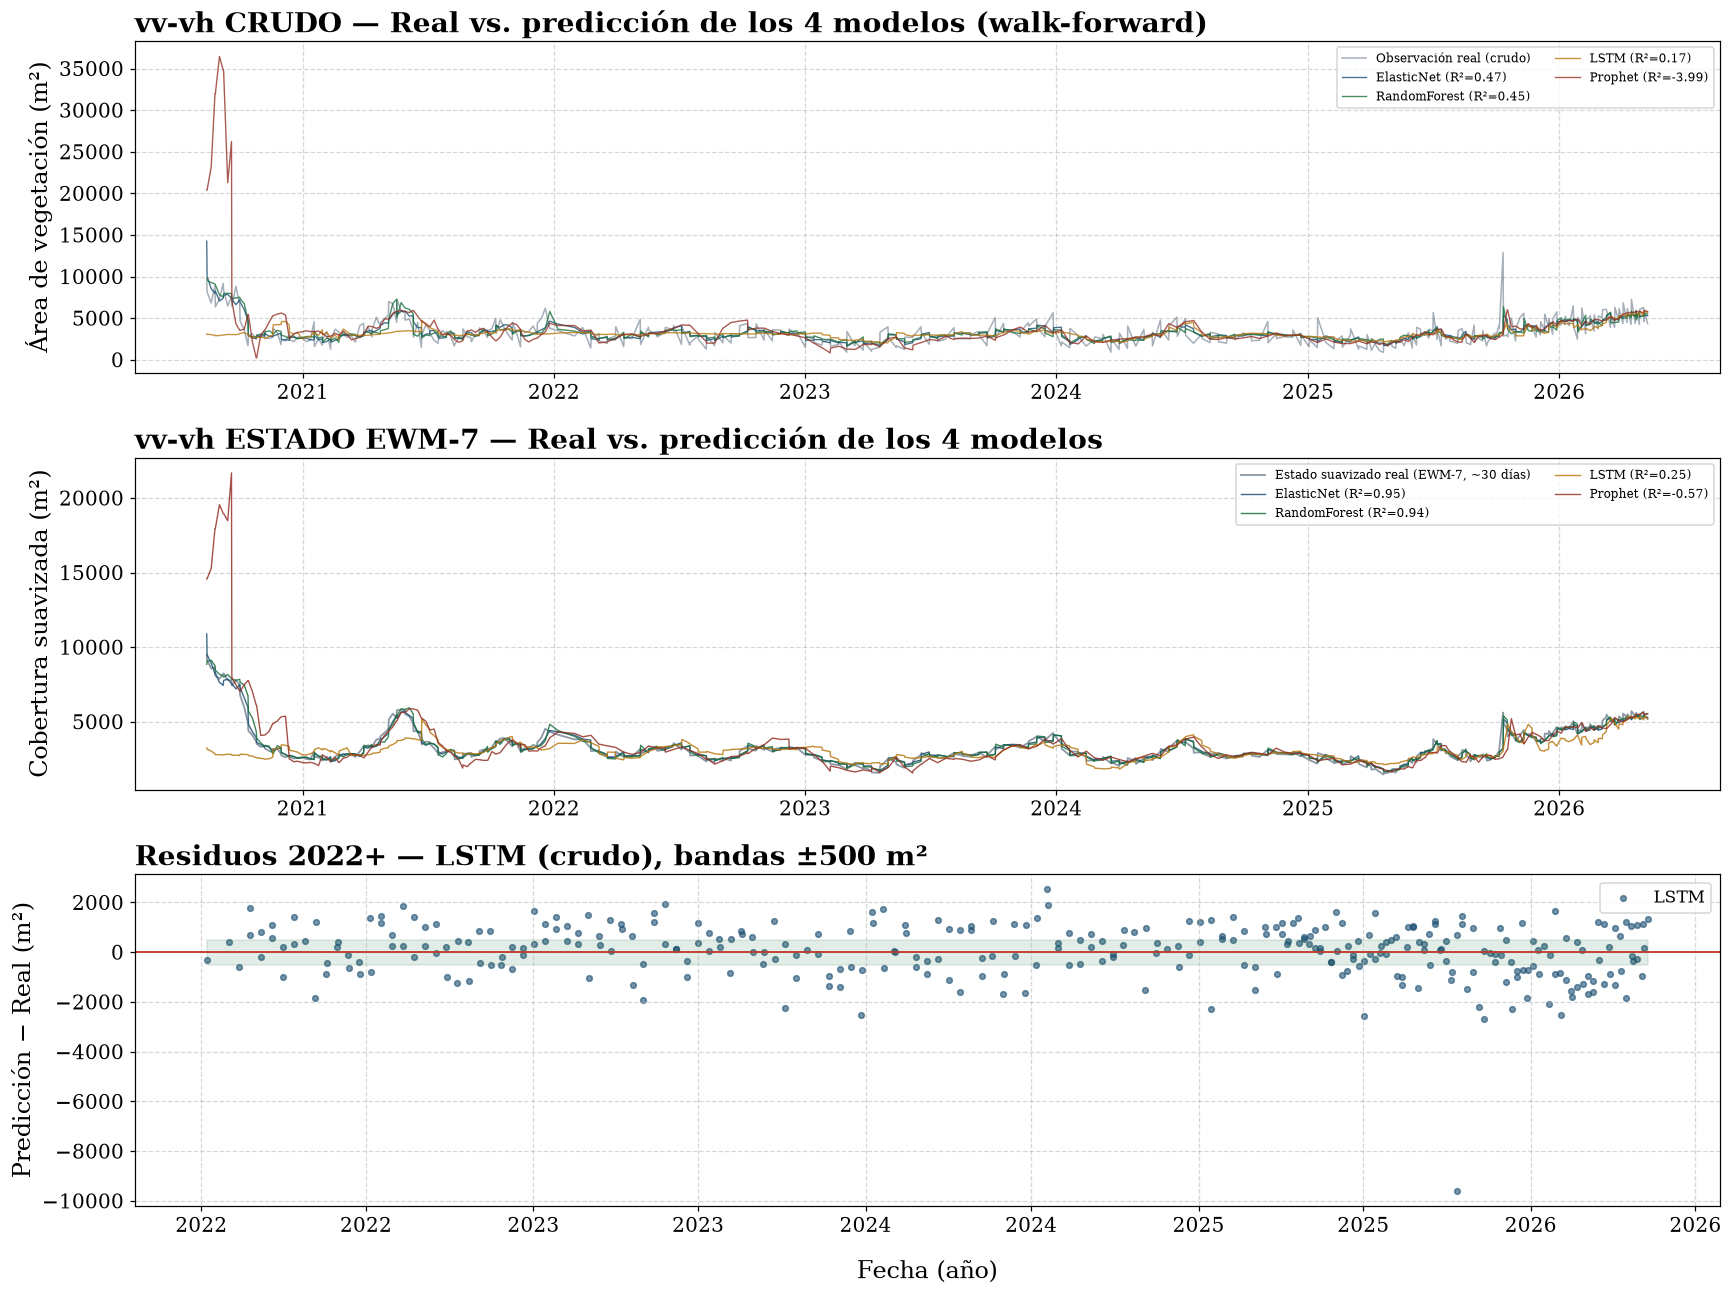

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Panel 1: target crudo, los 4 modelos
ax = axes[0]
ax.plot(preds['ElasticNet_crudo']['fecha'], preds['ElasticNet_crudo']['real'], lw=1.0, alpha=0.55,
        color='#5D6D7E', label='Observación real (crudo)')
for modelo, color in [('ElasticNet', '#1B4F72'), ('RandomForest', '#196F3D'),
                      ('LSTM', '#B9770E'), ('Prophet', '#943126')]:
    o = preds[f'{modelo}_crudo']
    ax.plot(o['fecha'], o['pred'], lw=0.9, alpha=0.8, color=color,
            label=f"{modelo} (R²={metricas(o['real'], o['pred'])['R2']:.2f})")
ax.set_title('vv-vh CRUDO — Real vs. predicción de los 4 modelos (walk-forward)', loc='left', fontweight='bold')
ax.set_ylabel('Área de vegetación (m²)')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='best', fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel 2: estado EWM-7, los 4 modelos
ax = axes[1]
ax.plot(preds['ElasticNet_estado']['fecha'], preds['ElasticNet_estado']['real'], lw=1.2, alpha=0.7,
        color='#5D6D7E', label='Estado suavizado real (EWM-7, ~30 días)')
for modelo, color in [('ElasticNet', '#1B4F72'), ('RandomForest', '#196F3D'),
                      ('LSTM', '#B9770E'), ('Prophet', '#943126')]:
    o = preds[f'{modelo}_estado']
    ax.plot(o['fecha'], o['pred'], lw=0.9, alpha=0.85, color=color,
            label=f"{modelo} (R²={metricas(o['real'], o['pred'])['R2']:.2f})")
ax.set_title('vv-vh ESTADO EWM-7 — Real vs. predicción de los 4 modelos', loc='left', fontweight='bold')
ax.set_ylabel('Cobertura suavizada (m²)')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='best', fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel 3: residuos 2022+ del mejor de los 4 modelos en el crudo
o = preds[f'{mejor_crudo}_crudo']
o22 = o[o['fecha'] >= '2022-01-01']
resid = o22['pred'] - o22['real']
ax = axes[2]
ax.scatter(o22['fecha'], resid, s=14, alpha=0.6, color='#1B4F72', label=f'{mejor_crudo}')
ax.axhline(0, color='#C0392B', lw=1.2)
ax.fill_between(o22['fecha'], -500, 500, alpha=0.12, color='#196F3D')
ax.set_title(f'Residuos 2022+ — {mejor_crudo} (crudo), bandas ±500 m²', loc='left', fontweight='bold')
ax.set_ylabel('Predicción − Real (m²)')
ax.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='best')

axes[-1].set_xlabel('Fecha (año)', labelpad=15)
plt.tight_layout()
plt.show()


## 9.10 Conclusiones del refactor ML

Con los datos disponibles (meteorología diaria IDEAM 2018→2026 sin presión + índice `vv-vh`
Sentinel-1 cada ~4-5 días) y el protocolo walk-forward sin fugas (pool completo ini=200, ~320
pasos, + sub-periodo stress 2022+):

- **Los 4 modelos superan a las reglas simples.** La diferencia más contundente está en el
  sub-periodo 2022+: la persistencia colapsa (R²≈-0.19) y la media móvil cae, mientras que
  ElasticNet/RandomForest/LSTM lo mantienen. Reportar siempre las referencias mínimas es lo que
  hace demostrable esa afirmación.
- **Ranking crudo (próxima pasada):** por RMSE 2022+ (periodo de validación más exigente),
  LSTM (R²≈0.36) > ElasticNet (≈0.35) > RandomForest (≈0.33) > Prophet (≈0.28); por el pool
  completo, ElasticNet es el más sólido (R²≈0.47 vs ~0.45 de RandomForest y ~0.17 de LSTM). El
  techo lo impone el **ruido intrínseco** (~±900 m² por pasada), no el modelo.
- **Ranking estado EWM-7 (~30 días, lo operativo):** ElasticNet es el tope (R²≈0.95 completo /
  0.92 en 2022+, ~94% de predicciones con error ≤500 m²), casi igualando a la persistencia, que
  aquí es dificilísima de batir por la fuerte inercia; le siguen RandomForest (0.94/0.92),
  Prophet (≈0.81 en 2022+) y LSTM (≈0.76). Ningún modelo deja de ser útil sobre el estado.
- **Por qué cada uno aporta:** ElasticNet = interpretable y estable (elige ~30 variables, dominan
  la memoria del índice); RandomForest = interacciones no lineales e importancia de features
  (meteorología ≈18-20%, memoria del índice ≈80%); LSTM = modelado secuencial sin lags
  manuales, el mejor del crudo reciente; Prophet = descomposición de tendencia/estacionalidad
  con regresores meteorológicos explícitos, de referencia en horizontes de mediano plazo.
- **Honestidad metodológica:** todos con features causales, splits temporales, escalado dentro
  del train, reentrenamiento en cadencia operativa (clásicos por observación; LSTM/Prophet cada
  25/10) y estabilidad multi-semilla (RF/LSTM) reportada. Un revisor puede reproducir las tablas
  sin ver los datos futuros.
